# Project Dataset To Regular Mesh

Notebook minimal pour projeter un dataset existant `base.bin + *.pkl` sur un maillage regulier deja cree.


In [1]:
from pathlib import Path
import os
import pickle
import sys

import numpy as np
from scipy.spatial import Delaunay, cKDTree

import dgl
import torch


def find_project_root(start: Path) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "python" / "create_dgl_dataset.py").exists():
            return path
    raise RuntimeError("Cannot find gnn_modulus_test project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from python.python_code.data_manip.extraction.telemac_file import TelemacFile
from python.create_dgl_dataset import add_mesh_info, extract_node_type, get_dgl_graph, unpack_dynamic_sample

os.chdir(PROJECT_ROOT)
PROJECT_ROOT


PosixPath('/users/m24046/m24046mrcr/gnn_modulus_test')

In [2]:
# A remplir.
# Source attendue : un mesh fin `.slf`, un graphe `*_base.bin` et des fichiers dynamiques `.pkl`.
FINE_MESH_SLF = "/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/T2V6_KV4_BuseV2.geo"
FINE_CLI = "/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/cas.conlim"
BOUNDARY_MATCH_TOL = 60.0
FINE_BASE_BIN = "/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/12_T2V6_KV4_Busev2_Q100_base.bin"
FINE_DYNAMIC_FILES = [
    "/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/08_T2V6_KV4_Busev2_Q5_0_0-92.pkl",
    "/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/09_T2V6_KV4_Busev2_Q10_0_0-92.pkl",
    "/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/10_T2V6_KV4_Busev2_Q30_0_0-92.pkl",
    "/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/11_T2V6_KV4_Busev2_Q50_0_0-92.pkl",
    "/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/12_T2V6_KV4_Busev2_Q100_0_0-92.pkl",
    "/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/13_T2V6_KV4_Busev2_Q2_0_0-92.pkl",
    "/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/04_T2V6_KV4_Busev3_Janv2018V3_0_0-94.pkl",
    "/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/06_T2V6_KV4_Busev3_1983V1_0_0-91.pkl",
    "/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/07_T2V6_KV4_Busev3_1910V2_0_0-47.pkl",
]
REGULAR_MESH_SLF = "/work/m24046/m24046mrcr/Test_Aube_regular/Aube_regular_50m.slf"
OUTPUT_DIR = "/work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m"
DATASET_NAME = "regular_50_dataset"
OVERWRITE = True

print({
    "FINE_MESH_SLF": FINE_MESH_SLF,
    "FINE_BASE_BIN": FINE_BASE_BIN,
    "FINE_DYNAMIC_FILES": FINE_DYNAMIC_FILES,
    "REGULAR_MESH_SLF": REGULAR_MESH_SLF,
    "OUTPUT_DIR": OUTPUT_DIR,
    "DATASET_NAME": DATASET_NAME,
    "OVERWRITE": OVERWRITE,
})


{'FINE_MESH_SLF': '/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/T2V6_KV4_BuseV2.geo', 'FINE_BASE_BIN': '/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/12_T2V6_KV4_Busev2_Q100_base.bin', 'FINE_DYNAMIC_FILES': ['/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/08_T2V6_KV4_Busev2_Q5_0_0-92.pkl', '/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/09_T2V6_KV4_Busev2_Q10_0_0-92.pkl', '/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/10_T2V6_KV4_Busev2_Q30_0_0-92.pkl', '/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/11_T2V6_KV4_Busev2_Q50_0_0-92.pkl', '/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/12_T2V6_KV4_Busev2_Q100_0_0-92.pkl', '/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/13_T2V6_KV4_Busev2_Q2_0_0-92.pkl', '/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/04_T2V6_KV4_Busev3_Janv2018V3_0_0-94.pkl', '/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/06_T2V6_KV4_Busev3_1983V1_0

In [3]:
def require_path(path_like: str, label: str) -> Path:
    path = Path(path_like).expanduser()
    if not path.exists():
        raise FileNotFoundError(f"{label} introuvable: {path}")
    return path


def build_interpolator(src_xy: np.ndarray, dst_xy: np.ndarray):
    tri = Delaunay(src_xy)
    simplex = tri.find_simplex(dst_xy)
    valid = simplex >= 0

    vertices = np.zeros((valid.sum(), 3), dtype=np.int64)
    barycentric = np.zeros((valid.sum(), 3), dtype=np.float32)

    if valid.any():
        transform = tri.transform[simplex[valid], :2]
        offset = tri.transform[simplex[valid], 2]
        delta = dst_xy[valid] - offset
        barycentric[:, :2] = np.einsum("ijk,ik->ij", transform, delta)
        barycentric[:, 2] = 1.0 - barycentric[:, 0] - barycentric[:, 1]
        vertices = tri.simplices[simplex[valid]]

    return {
        "valid": valid,
        "vertices": vertices,
        "barycentric": barycentric,
        "n_target": len(dst_xy),
    }


def project(values: np.ndarray, interp: dict):
    values = np.asarray(values)
    one_dim = values.ndim == 1
    if one_dim:
        values = values[:, None]

    out = np.zeros((interp["n_target"], values.shape[1]), dtype=np.float32)
    if interp["valid"].any():
        gathered = values[interp["vertices"]]
        out[interp["valid"]] = np.sum(
            gathered * interp["barycentric"][:, :, None],
            axis=1,
        ).astype(np.float32)

    if one_dim:
        return out[:, 0]
    return out


def build_regular_node_type_from_cli(
    fine_with_cli,
    fine_xy: np.ndarray,
    regular_xy: np.ndarray,
    tolerance: float,
):
    fine_node_type = extract_node_type(
        fine_with_cli.tri,
        fine_with_cli.get_bnd_info(),
    ).astype(np.float32)

    regular_node_type = np.zeros((len(regular_xy), fine_node_type.shape[1]), dtype=np.float32)
    regular_node_type[:, 0] = 1.0

    fine_labels = np.argmax(fine_node_type, axis=1)
    locked = np.zeros(len(regular_xy), dtype=bool)

    def assign_label(label: int, force_nearest: bool = False):
        mask = fine_labels == label
        if not mask.any():
            return

        src_xy = fine_xy[mask]
        src_type = fine_node_type[mask]

        tree = cKDTree(src_xy)
        distances, indices = tree.query(regular_xy)
        matched = (distances <= tolerance) & (~locked)

        regular_node_type[matched] = src_type[indices[matched]]

        if force_nearest:
            _, nearest_regular = cKDTree(regular_xy).query(src_xy)
            regular_node_type[nearest_regular] = src_type
            locked[nearest_regular] = True

    assign_label(2, force_nearest=True)
    assign_label(1, force_nearest=False)
    assign_label(3, force_nearest=False)

    return regular_node_type


def node_type_counts(node_type: np.ndarray):
    labels = np.argmax(np.asarray(node_type, dtype=np.float32), axis=1)
    return np.bincount(labels, minlength=node_type.shape[1])

def output_dynamic_name(path: Path) -> str:
    parts = path.stem.split("_")
    if len(parts) < 5:
        raise ValueError(f"Nom dynamique non supporte: {path.name}")

    section = next((part for part in parts if part.startswith("T") and "V" in part), None)
    if section is None:
        raise ValueError(f"Section introuvable dans: {path.name}")

    traj = parts[-2]
    chunk = parts[-1]
    if not traj.isdigit() or "-" not in chunk:
        raise ValueError(f"Trajectoire ou chunk non supporte dans: {path.name}")

    case_name = next((part for part in parts if part.startswith("Q") and part[1:].isdigit()), None)
    if case_name is None:
        case_name = parts[-3]

    return f"{DATASET_NAME}_{section}_{case_name}_{traj}_{chunk}{path.suffix}"


In [4]:
if not FINE_CLI:
    raise ValueError("Renseigne FINE_CLI avant de lancer la projection du base.bin regulier.")

fine_mesh_path = require_path(FINE_MESH_SLF, "FINE_MESH_SLF")
fine_cli_path = require_path(FINE_CLI, "FINE_CLI")
fine_base_path = require_path(FINE_BASE_BIN, "FINE_BASE_BIN")
regular_mesh_path = require_path(REGULAR_MESH_SLF, "REGULAR_MESH_SLF")
dynamic_paths = [require_path(path, f"FINE_DYNAMIC_FILE[{i}]") for i, path in enumerate(FINE_DYNAMIC_FILES) if path]
if not dynamic_paths:
    raise ValueError("FINE_DYNAMIC_FILES is empty.")

output_dir = Path(OUTPUT_DIR).expanduser()
output_dir.mkdir(parents=True, exist_ok=True)

fine_mesh = TelemacFile(str(fine_mesh_path))
fine_with_cli = TelemacFile(str(fine_mesh_path), bnd_file=str(fine_cli_path))
regular_mesh = TelemacFile(str(regular_mesh_path))
fine_graphs, _ = dgl.load_graphs(str(fine_base_path))
fine_base_graph = fine_graphs[0]

fine_xy, fine_triangles = add_mesh_info(fine_mesh)
regular_xy, regular_triangles = add_mesh_info(regular_mesh)
interp = build_interpolator(fine_xy, regular_xy)

fine_static = np.asarray(fine_base_graph.ndata["static"], dtype=np.float32)
fine_friction = fine_static[:, 4]
fine_bottom = fine_static[:, 5]

print("fine mesh:", fine_mesh_path)
print("fine cli:", fine_cli_path)
print("fine base:", fine_base_path)
print("regular mesh:", regular_mesh_path)
print("output dir:", output_dir)
print("boundary match tol:", BOUNDARY_MATCH_TOL)
print("dynamic files:")
for path in dynamic_paths:
    print(" -", path)
print("fine nodes:", len(fine_xy), "fine triangles:", len(fine_triangles))
print("regular nodes:", len(regular_xy), "regular triangles:", len(regular_triangles))
print("valid projected points:", int(interp["valid"].sum()), "/", len(regular_xy))


fine mesh: /work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/T2V6_KV4_BuseV2.geo
fine cli: /work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/cas.conlim
fine base: /work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/12_T2V6_KV4_Busev2_Q100_base.bin
regular mesh: /work/m24046/m24046mrcr/Test_Aube_regular/Aube_regular_50m.slf
output dir: /work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m
boundary match tol: 60.0
dynamic files:
 - /work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/08_T2V6_KV4_Busev2_Q5_0_0-92.pkl
 - /work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/09_T2V6_KV4_Busev2_Q10_0_0-92.pkl
 - /work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/10_T2V6_KV4_Busev2_Q30_0_0-92.pkl
 - /work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/11_T2V6_KV4_Busev2_Q50_0_0-92.pkl
 - /work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/12_T2V6_KV4_Busev2_Q100_0_0-92.pkl
 - /work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/13

In [5]:
# Replace the old nearest-neighbour projection of node_type.
# The boundary one-hot is rebuilt from the fine mesh + CLI so that
# prescribed boundary conditions are preserved on the regular grid.
base_path = output_dir / f"{DATASET_NAME}_base.bin"
if base_path.exists() and not OVERWRITE:
    raise FileExistsError(base_path)

regular_node_type = build_regular_node_type_from_cli(
    fine_with_cli,
    fine_xy,
    regular_xy,
    BOUNDARY_MATCH_TOL,
)
regular_friction = project(fine_friction, interp)
regular_bottom = project(fine_bottom, interp)

regular_static = np.concatenate([
    regular_node_type,
    regular_friction[:, None],
    regular_bottom[:, None],
], axis=1).astype(np.float32)

regular_graph, regular_edge_features = get_dgl_graph(regular_mesh.tri)
regular_graph.edata["x"] = torch.as_tensor(regular_edge_features, dtype=torch.float32)
regular_graph.ndata["static"] = torch.as_tensor(regular_static, dtype=torch.float32)
dgl.save_graphs(str(base_path), [regular_graph])

print("base graph written:", base_path)
print("static shape:", tuple(regular_graph.ndata["static"].shape))
print("regular node type counts:", node_type_counts(regular_node_type).tolist())


base graph written: /work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m/regular_50_dataset_base.bin
static shape: (16905, 6)
regular node type counts: [15576, 45, 1, 1283]


In [6]:
for path in dynamic_paths:
    with open(path, "rb") as handle:
        dynamic_data = pickle.load(handle)

    projected_data = []
    for sample in dynamic_data:
        x, y, ts = unpack_dynamic_sample(sample)
        x_regular = project(x, interp)
        y_regular = project(y, interp)
        projected_data.append((x_regular, y_regular, ts))

    output_path = output_dir / output_dynamic_name(path)
    if output_path.exists() and not OVERWRITE:
        raise FileExistsError(output_path)

    with open(output_path, "wb") as handle:
        pickle.dump(projected_data, handle)

    print("written:", output_path, "| samples:", len(projected_data))


written: /work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m/regular_50_dataset_T2V6_Q5_0_0-92.pkl | samples: 92
written: /work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m/regular_50_dataset_T2V6_Q10_0_0-92.pkl | samples: 92
written: /work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m/regular_50_dataset_T2V6_Q30_0_0-92.pkl | samples: 92
written: /work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m/regular_50_dataset_T2V6_Q50_0_0-92.pkl | samples: 92
written: /work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m/regular_50_dataset_T2V6_Q100_0_0-92.pkl | samples: 92
written: /work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m/regular_50_dataset_T2V6_Q2_0_0-92.pkl | samples: 92
written: /work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m/regular_50_dataset_T2V6_Janv2018V3_0_0-94.pkl | samples: 94
written: /work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m/regular_50_dataset_T2V6_1983V1_0_0-91.pkl | samples: 91
written: /work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m/

In [7]:
import matplotlib.tri as mtri
import matplotlib.pyplot as plt

FINE_PKL = "/work/m24046/m24046mrcr/Test_Aube_regular/original_dataset/07_T2V6_KV4_Busev3_1910V2_0_0-47.pkl"
REGULAR_PKL = "/work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m/regular_50_dataset_T2V6_1910V2_0_0-47.pkl"

SAMPLE_ID = 35


fine_mesh = TelemacFile(FINE_MESH_SLF)
regular_mesh = TelemacFile(REGULAR_MESH_SLF)

fine_xy, fine_triangles = add_mesh_info(fine_mesh)
regular_xy, regular_triangles = add_mesh_info(regular_mesh)

fine_tri = mtri.Triangulation(fine_xy[:, 0], fine_xy[:, 1], fine_triangles)
regular_tri = mtri.Triangulation(regular_xy[:, 0], regular_xy[:, 1], regular_triangles)

with open(FINE_PKL, "rb") as f:
    fine_data = pickle.load(f)

with open(REGULAR_PKL, "rb") as f:
    regular_data = pickle.load(f)

x_fine, y_fine, ts_fine = unpack_dynamic_sample(fine_data[SAMPLE_ID])
x_reg, y_reg, ts_reg = unpack_dynamic_sample(regular_data[SAMPLE_ID])

print("ts fine   :", ts_fine)
print("ts regular:", ts_reg)

ts fine   : 35
ts regular: 35


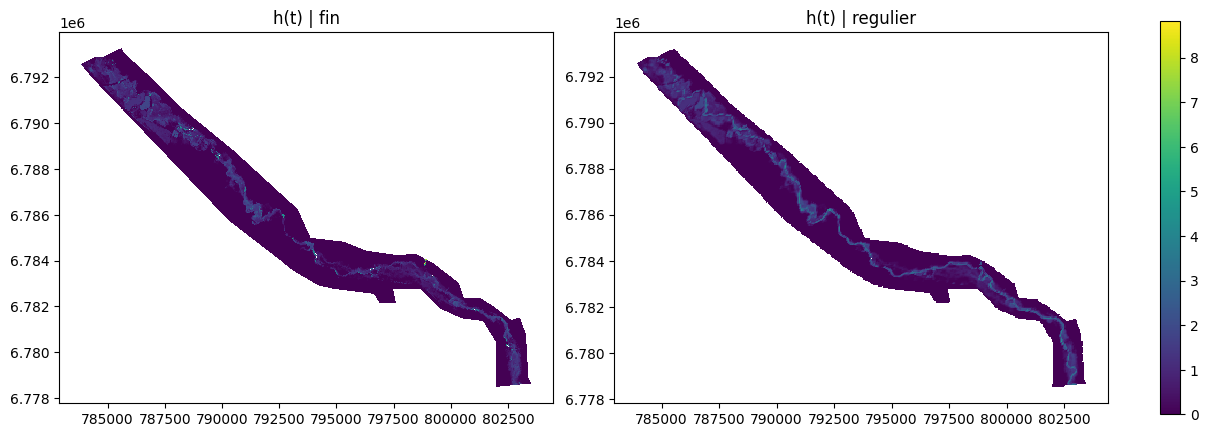

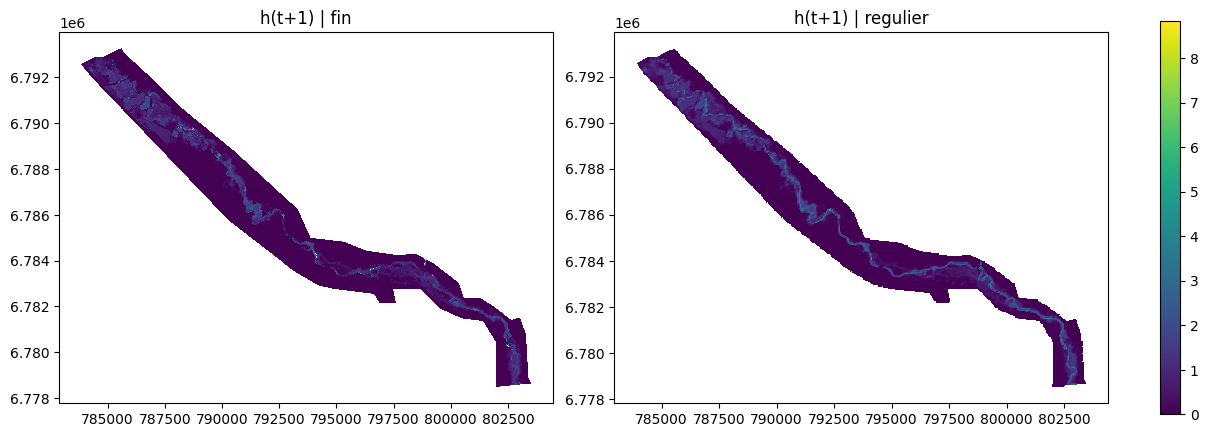

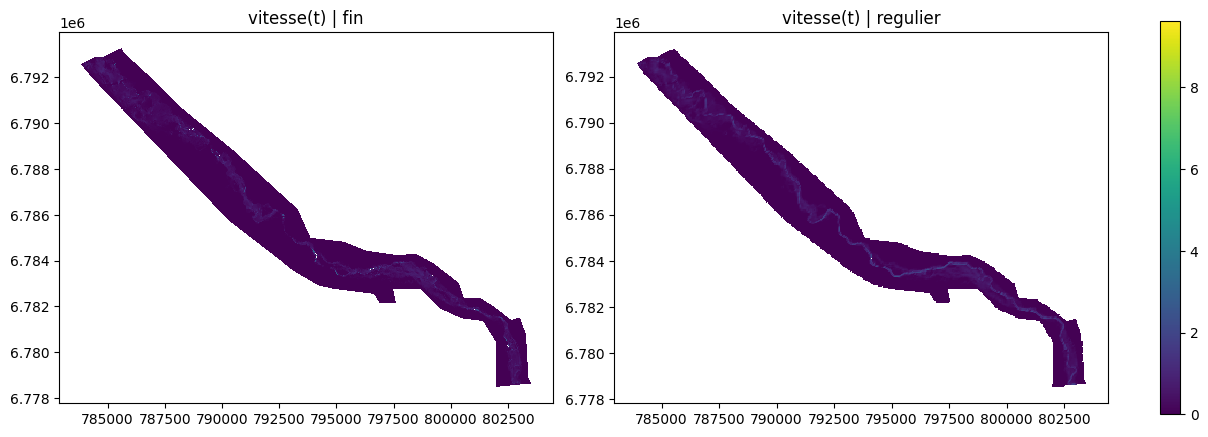

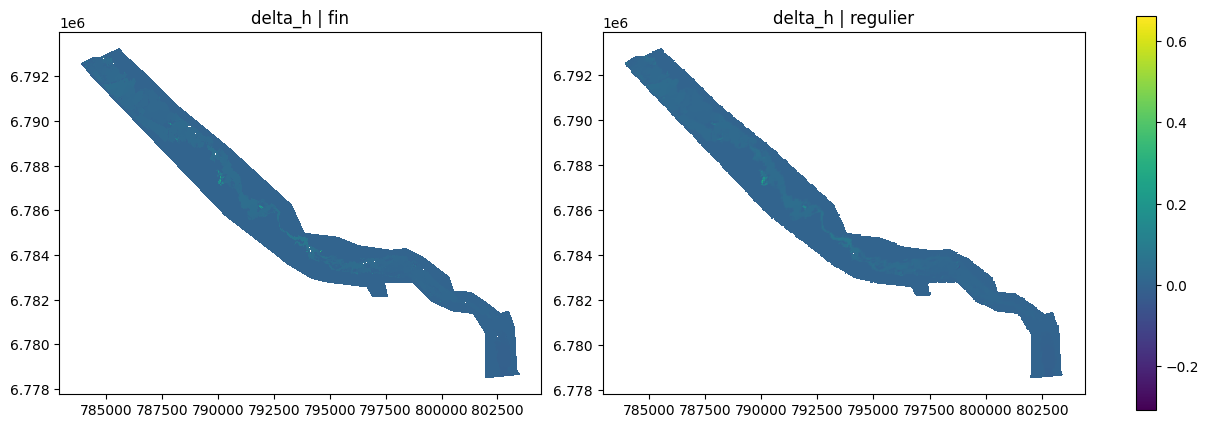

In [8]:
def plot_pair(title, fine_values, regular_values):
    vmin = min(np.nanmin(fine_values), np.nanmin(regular_values))
    vmax = max(np.nanmax(fine_values), np.nanmax(regular_values))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    a0 = axes[0].tripcolor(fine_tri, fine_values, cmap="viridis", vmin=vmin, vmax=vmax)
    a1 = axes[1].tripcolor(regular_tri, regular_values, cmap="viridis", vmin=vmin, vmax=vmax)

    axes[0].set_title(f"{title} | fin")
    axes[1].set_title(f"{title} | regulier")

    for ax in axes:
        ax.set_aspect("equal")

    fig.colorbar(a1, ax=axes, shrink=0.8)
    plt.show()
    
plot_pair("h(t)", x_fine[:, 0], x_reg[:, 0])

plot_pair("h(t+1)", x_fine[:, 0] + y_fine[:, 0], x_reg[:, 0] + y_reg[:, 0])

plot_pair(
    "vitesse(t)",
    np.sqrt(x_fine[:, 1]**2 + x_fine[:, 2]**2),
    np.sqrt(x_reg[:, 1]**2 + x_reg[:, 2]**2),
)

plot_pair("delta_h", y_fine[:, 0], y_reg[:, 0])

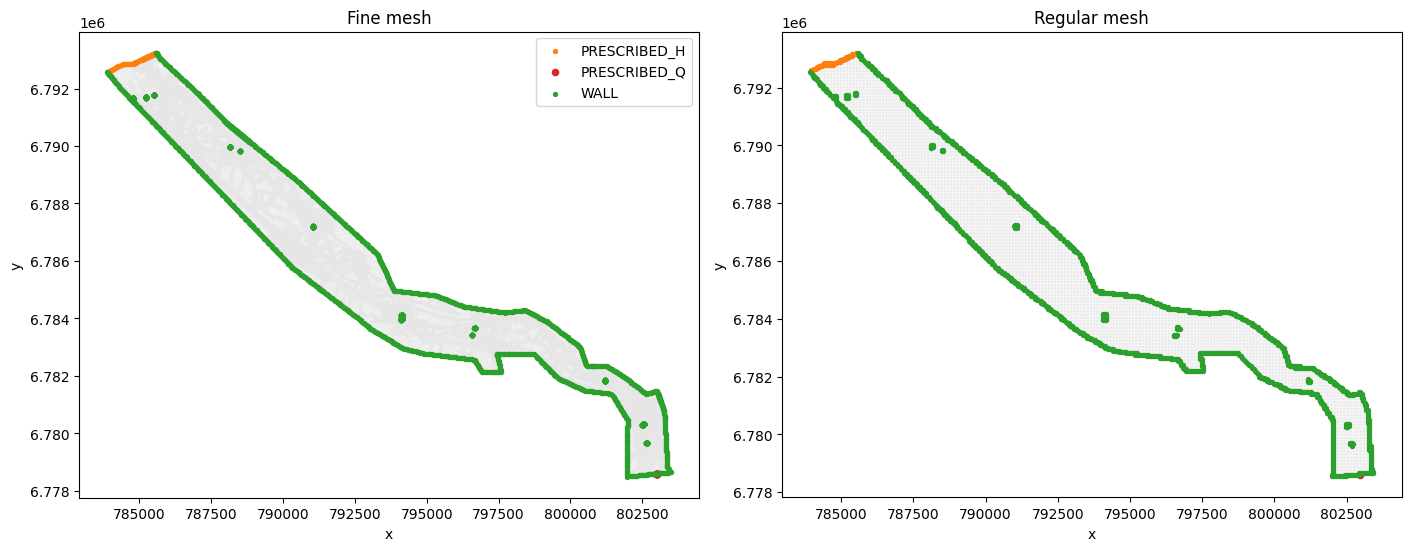

fine counts: [310312, 100, 10, 3099]
regular counts: [15576, 45, 1, 1283]
classes: 0=NORMAL, 1=PRESCRIBED_H, 2=PRESCRIBED_Q, 3=WALL_BOUNDARY


In [9]:
fine_node_type = np.asarray(fine_base_graph.ndata["static"], dtype=np.float32)[:, :4]
regular_graphs, _ = dgl.load_graphs(str(base_path))
regular_base_graph = regular_graphs[0]
regular_node_type = np.asarray(regular_base_graph.ndata["static"], dtype=np.float32)[:, :4]

fine_labels = np.argmax(fine_node_type, axis=1)
regular_labels = np.argmax(regular_node_type, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)

plots = [
    (axes[0], fine_xy, fine_triangles, fine_labels, "Fine mesh"),
    (axes[1], regular_xy, regular_triangles, regular_labels, "Regular mesh"),
]

for ax, xy, triangles, labels, title in plots:
    ax.triplot(xy[:, 0], xy[:, 1], triangles, color="0.9", linewidth=0.15)
    ax.scatter(xy[labels == 1, 0], xy[labels == 1, 1], s=8, c="tab:orange", label="PRESCRIBED_H")
    ax.scatter(xy[labels == 2, 0], xy[labels == 2, 1], s=20, c="tab:red", label="PRESCRIBED_Q")
    ax.scatter(xy[labels == 3, 0], xy[labels == 3, 1], s=8, c="tab:green", label="WALL")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")

axes[0].legend()
plt.show()

print("fine counts:", np.bincount(fine_labels, minlength=4).tolist())
print("regular counts:", np.bincount(regular_labels, minlength=4).tolist())
print("classes: 0=NORMAL, 1=PRESCRIBED_H, 2=PRESCRIBED_Q, 3=WALL_BOUNDARY")

In [14]:
from pathlib import Path
import pickle
import re
import shutil

import numpy as np

from python.create_dgl_dataset import load_liq_hydrograph, unpack_dynamic_sample

INPUT_DIR = Path("/work/m24046/m24046mrcr/Test_Aube_regular/dataset_50m")
INPUT_BASE_BIN = INPUT_DIR / "regular_50_dataset_base.bin"
OUTPUT_DIR = INPUT_DIR.parent / "dataset_50m_short"
PKL_GLOB = "regular_50_dataset_*.pkl"

DT_SECONDS = 14400
WINDOW = 40

HYDRO_BY_CASE = {
    "Q5": Path("/work/m24046/m24046mrcr/Test_Aube_regular/liqu/T2_Q5_V1.liq"),
    "Q10": Path("/work/m24046/m24046mrcr/Test_Aube_regular/liqu/T2_Q10_V1.liq"),
    "Q30": Path("/work/m24046/m24046mrcr/Test_Aube_regular/liqu/T2_Q30_V1.liq"),
    "Q50": Path("/work/m24046/m24046mrcr/Test_Aube_regular/liqu/T2_Q50_V1.liq"),
    "Q100": Path("/work/m24046/m24046mrcr/Test_Aube_regular/liqu/T2_Q100_V1.liq"),
    "Q2": Path("/work/m24046/m24046mrcr/Test_Aube_regular/liqu/T2_Q2_V1.liq"),
    "Janv2018V3": Path("/work/m24046/m24046mrcr/Test_Aube_regular/liqu/T2_Q_Janvier2018_V3.liq"),
    "1983V1": Path("/work/m24046/m24046mrcr/Test_Aube_regular/liqu/T2_Q_1983_V1.liq"),
    "1910V2": Path("/work/m24046/m24046mrcr/Test_Aube_regular/liqu/T2_Q_1910_V2.liq"),
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(INPUT_BASE_BIN, OUTPUT_DIR / INPUT_BASE_BIN.name)


def get_case_name(path):
    parts = path.stem.split("_")
    if len(parts) < 3:
        raise ValueError(f"Nom non supporte: {path.name}")
    return parts[-3]


def peak_sample_index(samples, liq_path, dt_seconds):
    t_hydro, q_hydro = load_liq_hydrograph(liq_path)
    peak_time_seconds = float(t_hydro[np.argmax(q_hydro)])

    sample_times_seconds = []
    for sample in samples:
        _, _, ts = unpack_dynamic_sample(sample)
        if ts is None:
            raise ValueError("Les samples doivent contenir un ts pour utiliser les .liq.")
        sample_times_seconds.append(float(ts) * dt_seconds)

    sample_times_seconds = np.asarray(sample_times_seconds, dtype=np.float64)
    return int(np.argmin(np.abs(sample_times_seconds - peak_time_seconds)))


def centered_bounds(n, center, window):
    if n < window:
        raise ValueError(f"{n} samples, il en faut au moins {window}")

    start = max(0, center - window // 2)
    stop = start + window

    if stop > n:
        stop = n
        start = stop - window

    return start, stop


def build_output_name(path, start, stop):
    stem = re.sub(r"_0_\d+-\d+$", f"_0_{start}-{stop - 1}", path.stem)
    if stem == path.stem:
        stem = f"{path.stem}_{start}-{stop - 1}"
    return f"{stem}{path.suffix}"


for pkl_path in sorted(INPUT_DIR.glob(PKL_GLOB)):
    case_name = get_case_name(pkl_path)

    if case_name not in HYDRO_BY_CASE:
        print(f"skip: {pkl_path.name} | pas de .liq associe")
        continue

    with open(pkl_path, "rb") as f:
        samples = pickle.load(f)

    peak_idx = peak_sample_index(samples, HYDRO_BY_CASE[case_name], DT_SECONDS)
    start, stop = centered_bounds(len(samples), peak_idx, WINDOW)
    reduced_samples = samples[start:stop]

    output_path = OUTPUT_DIR / build_output_name(pkl_path, start, stop)
    with open(output_path, "wb") as f:
        pickle.dump(reduced_samples, f)

    print(
        f"{pkl_path.name} -> {output_path.name} | "
        f"case={case_name} | peak={peak_idx} | {start}:{stop} | "
        f"{len(samples)} -> {len(reduced_samples)}"
    )

print("done:", OUTPUT_DIR)

regular_50_dataset_T2V6_1910V2_0_0-47.pkl -> regular_50_dataset_T2V6_1910V2_0_0-39.pkl | case=1910V2 | peak=17 | 0:40 | 47 -> 40
regular_50_dataset_T2V6_1983V1_0_0-91.pkl -> regular_50_dataset_T2V6_1983V1_0_7-46.pkl | case=1983V1 | peak=27 | 7:47 | 91 -> 40
regular_50_dataset_T2V6_Janv2018V3_0_0-94.pkl -> regular_50_dataset_T2V6_Janv2018V3_0_34-73.pkl | case=Janv2018V3 | peak=54 | 34:74 | 94 -> 40
regular_50_dataset_T2V6_Q100_0_0-92.pkl -> regular_50_dataset_T2V6_Q100_0_0-39.pkl | case=Q100 | peak=20 | 0:40 | 92 -> 40
regular_50_dataset_T2V6_Q10_0_0-92.pkl -> regular_50_dataset_T2V6_Q10_0_0-39.pkl | case=Q10 | peak=17 | 0:40 | 92 -> 40
regular_50_dataset_T2V6_Q2_0_0-92.pkl -> regular_50_dataset_T2V6_Q2_0_0-39.pkl | case=Q2 | peak=17 | 0:40 | 92 -> 40
regular_50_dataset_T2V6_Q30_0_0-92.pkl -> regular_50_dataset_T2V6_Q30_0_0-39.pkl | case=Q30 | peak=17 | 0:40 | 92 -> 40
regular_50_dataset_T2V6_Q50_0_0-92.pkl -> regular_50_dataset_T2V6_Q50_0_0-39.pkl | case=Q50 | peak=17 | 0:40 | 92 -> 40

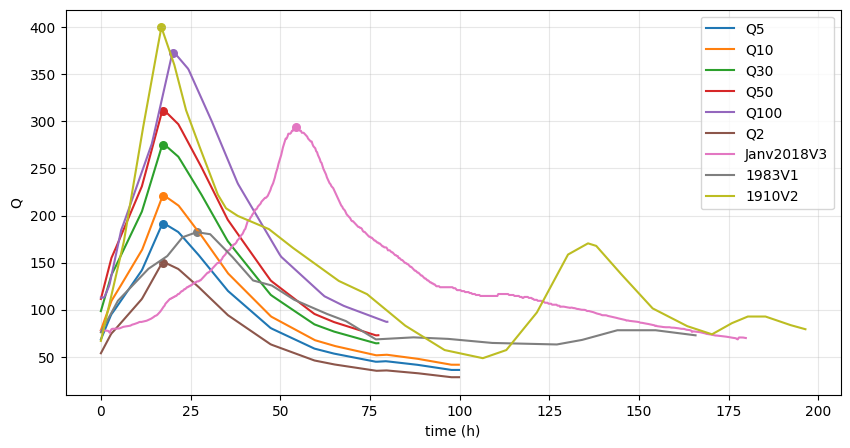

In [15]:
plt.figure(figsize=(10, 5))

for case_name, liq_path in HYDRO_BY_CASE.items():
    t_hydro, q_hydro = load_liq_hydrograph(liq_path)
    peak_idx = int(np.argmax(q_hydro))
    peak_t_hours = float(t_hydro[peak_idx] / 14400)
    peak_q = float(q_hydro[peak_idx])

    plt.plot(t_hydro / 14400, q_hydro, label=case_name)
    plt.scatter([peak_t_hours], [peak_q], s=30)

plt.xlabel("time (h)")
plt.ylabel("Q")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()